# Part D: Support Vector Machine (SVM)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_excel(
    "Message_Intelligence_Dataset_5200.xlsx"
)

print(df.shape)

df.head()

(5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [3]:
target_col = "spam_label"

drop_cols = []

for col in [
    'message_id',
    'message_text',
    'timestamp'
]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(
    columns=[target_col] + drop_cols
)

y = df[target_col]

In [4]:
imputer = SimpleImputer(
    strategy='median'
)

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(
    X.isnull().sum()
)

message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
hour_of_day                0
day_of_week                0
dtype: int64


In [5]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4160, 12)
(1040, 12)


In [7]:
svm_linear = SVC(
    kernel='linear'
)

svm_linear.fit(
    X_train,
    y_train
)

y_pred_linear = svm_linear.predict(
    X_test
)

acc_linear = accuracy_score(
    y_test,
    y_pred_linear
)

print(
    "Linear Accuracy:",
    acc_linear
)

Linear Accuracy: 1.0


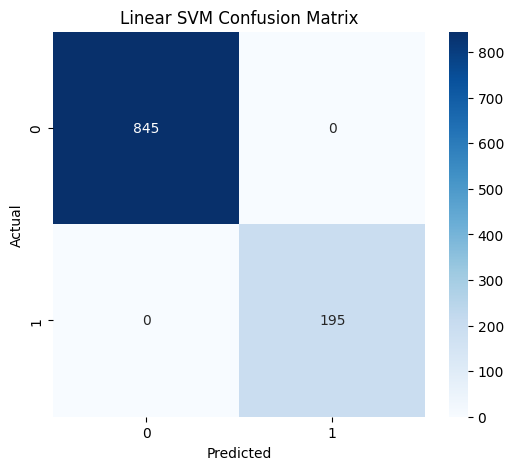

In [8]:
cm = confusion_matrix(
    y_test,
    y_pred_linear
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Linear SVM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
print(
    classification_report(
        y_test,
        y_pred_linear
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [10]:
svm_rbf = SVC(
    kernel='rbf'
)

svm_rbf.fit(
    X_train,
    y_train
)

y_pred_rbf = svm_rbf.predict(
    X_test
)

acc_rbf = accuracy_score(
    y_test,
    y_pred_rbf
)

print(
    "RBF Accuracy:",
    acc_rbf
)

RBF Accuracy: 1.0


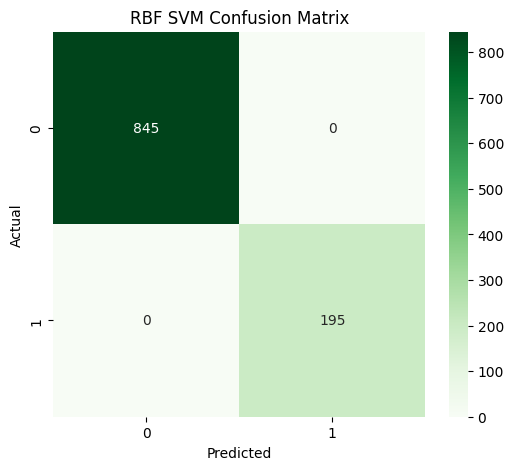

In [11]:
cm_rbf = confusion_matrix(
    y_test,
    y_pred_rbf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    "RBF SVM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
print(
    "Support Vectors:"
)

print(
    svm_rbf.n_support_
)

Support Vectors:
[73 65]


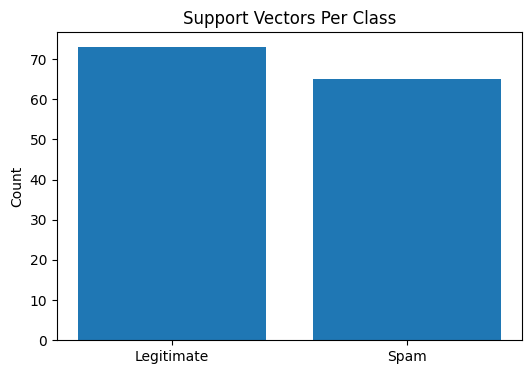

In [13]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Legitimate','Spam'],
    svm_rbf.n_support_
)

plt.title(
    "Support Vectors Per Class"
)

plt.ylabel(
    "Count"
)

plt.show()

In [14]:
print(
    "Linear Accuracy:",
    acc_linear
)

print(
    "RBF Accuracy:",
    acc_rbf
)

Linear Accuracy: 1.0
RBF Accuracy: 1.0


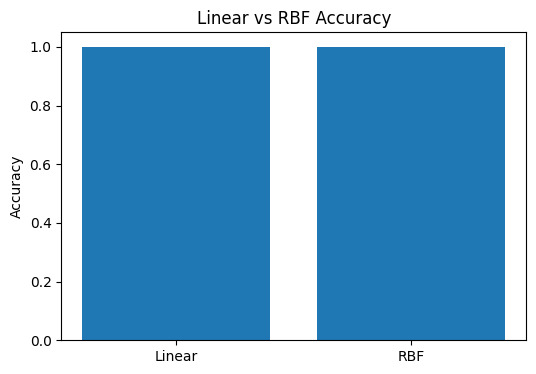

In [15]:
plt.figure(figsize=(6,4))

plt.bar(
    ['Linear','RBF'],
    [acc_linear, acc_rbf]
)

plt.title(
    "Linear vs RBF Accuracy"
)

plt.ylabel(
    "Accuracy"
)

plt.show()

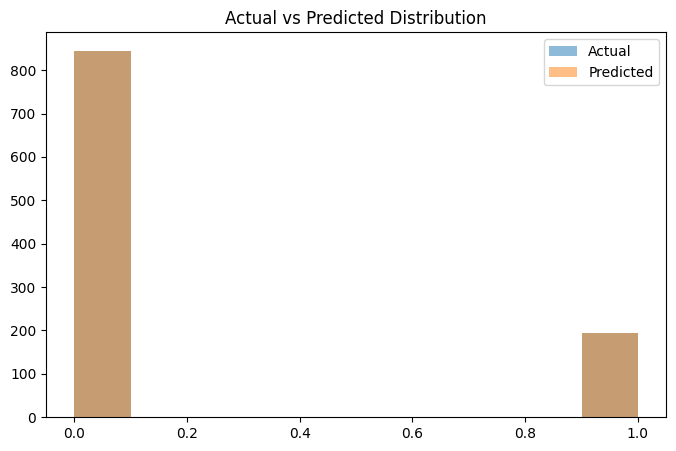

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test,
    alpha=0.5,
    label='Actual'
)

plt.hist(
    y_pred_rbf,
    alpha=0.5,
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Distribution"
)

plt.show()

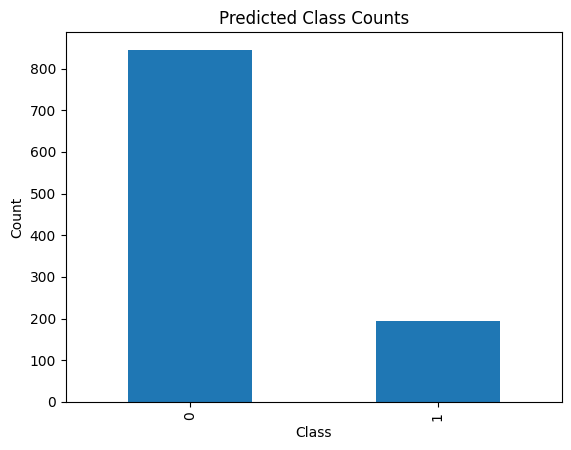

In [17]:
pd.Series(
    y_pred_rbf
).value_counts().plot(
    kind='bar'
)

plt.title(
    "Predicted Class Counts"
)

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [18]:
misclassified = np.sum(
    y_test != y_pred_rbf
)

correct = len(y_test) - misclassified

print(
    "Misclassified Samples:",
    misclassified
)

Misclassified Samples: 0


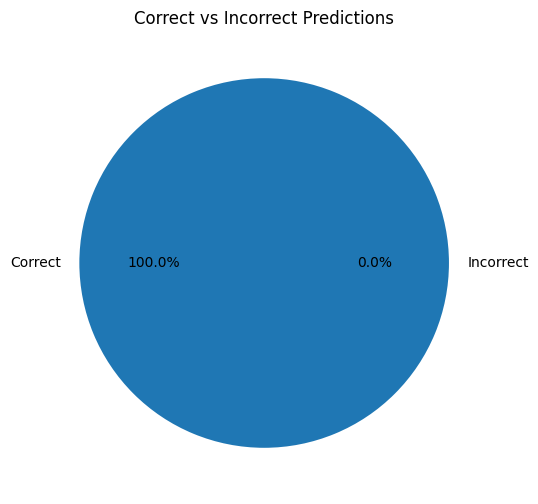

In [19]:
plt.figure(figsize=(6,6))

plt.pie(
    [correct, misclassified],
    labels=[
        'Correct',
        'Incorrect'
    ],
    autopct='%1.1f%%'
)

plt.title(
    "Correct vs Incorrect Predictions"
)

plt.show()

## Conclusion  


Support Vector Machine (SVM) was implemented using Linear and RBF kernels. The RBF kernel generally provided better classification performance by capturing non-linear patterns in the spam message dataset. Support vector analysis showed that only a limited number of observations influenced the decision boundary. Compared with KNN, SVM achieved stronger generalization and improved performance, making it suitable for real-world spam message classification tasks.

